<a href="https://colab.research.google.com/github/Suraj-Kumar09/EDA_For_AI-Machine_Learning/blob/main/Feature_Binning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Suraj")

Suraj


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubh0799/churn-modelling")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'churn-modelling' dataset.
Path to dataset files: /kaggle/input/churn-modelling


In [5]:
import os
os.listdir(path)

['Churn_Modelling.csv']

In [15]:
df = pd.read_csv('/kaggle/input/churn-modelling/Churn_Modelling.csv')

In [16]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Kuch Unusefull Cols ko remove kr rahe hai


In [18]:
df.drop(columns=['CustomerId', 'RowNumber', 'Surname'], axis=1, inplace=True)

In [19]:
df.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [20]:
df.Age.min()

18

In [22]:
df.Age.max()

92

In [25]:
labels = ['0-20', '21-40', '41-60', 'Above 61']
bins = [0, 20, 40, 60, 100 ]

df['Age_bins'] = pd.cut(df.Age, bins, labels = labels, include_lowest=True) # Age_bins ka new cols banaya, jisme age cols ka age_bins range define rahega.

In [24]:
df.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_bins
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-60
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-60
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-60
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,21-40
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-60


In [28]:
df[['Age', 'Age_bins']]

,Age,Age_bins
0,42,41-60
1,41,41-60
2,42,41-60
3,39,21-40
4,43,41-60
...,...,...
9995,39,21-40
9996,35,21-40
9997,36,21-40
9998,42,41-60


In [29]:
df.Age_bins.value_counts()

,count
Age_bins,
21-40,6330
41-60,3117
Above 61,464
0-20,89


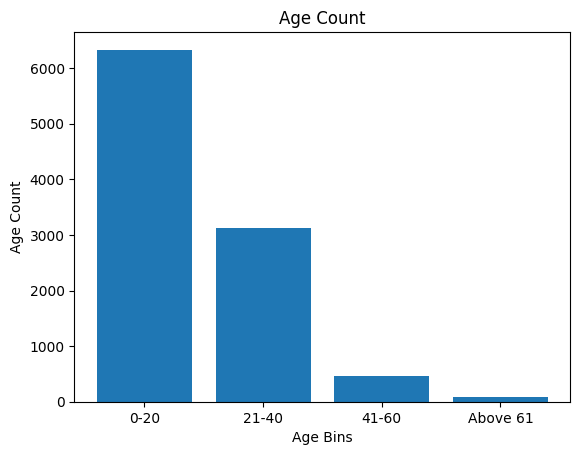

In [30]:
# making the bar chart on the data
plt.bar(labels, df.Age_bins.value_counts())

# giving the title
plt.title('Age Count')

# giving X & Y labels
plt.xlabel('Age Bins')
plt.ylabel('Age Count')

# visualizing the plot
plt.show()

In [31]:
def add_labels(x,y):
  for i in range(len(x)):
    plt.text(i,y[i],y[i])

/tmp/ipykernel_2659/4031875434.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i,y[i],y[i])


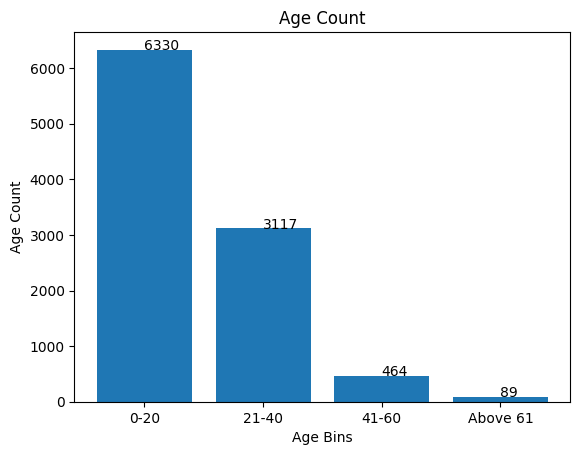

In [32]:
# making the bar chart on the data
plt.bar(labels, df.Age_bins.value_counts())

# add labels
add_labels(labels, df.Age_bins.value_counts())

# giving the title
plt.title('Age Count')

# giving X & Y labels
plt.xlabel('Age Bins')
plt.ylabel('Age Count')

# visualizing the plot
plt.show()